# Fig Complexity Gdp


In [1]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


## Scientific Complexity across Polities

For six historical polities, this notebook computes:

- **Scientific complexity**: Shannon entropy of the per-bin top-10 scientific occupations in 50-year bins.
- **Occupation breakdown**: stacked bar chart (log scale) of the top-10 scientific occupations over time, with the complexity curve overlaid.

### 1. Setup

Load the list of scientific occupation labels from the database and define
a simple Shannon entropy function.

In [ ]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
from collections import Counter

DB = DB_PATH


def shannon_entropy(counts, top_n=10):
    """Shannon entropy (bits) of the top-n most frequent items in a Counter."""
    top = [c for _, c in counts.most_common(top_n)]
    total = sum(top)
    if total == 0:
        return np.nan
    p = np.array(top) / total
    return -np.sum(p * np.log2(p))


# Load scientific occupation labels from the database
conn = sqlite3.connect(DB)
SCIENTIFIC_OCCUPATIONS = {
    row[0] for row in conn.execute(
        "SELECT DISTINCT lower(name_en) FROM occupations WHERE meta_occupation = 'scientist'"
    )
}
conn.close()

print(f'Loaded {len(SCIENTIFIC_OCCUPATIONS)} scientific occupation labels')


### 2. Entropy formula

$H_t = -\sum_{i=1}^{n} p_{i,t} \log_2(p_{i,t})$

where $p_{i,t} = c_{i,t} / \sum_j c_{j,t}$ is the share of the $i$-th occupation
among the top-$n$ scientific occupations in 50-year bin $t$.
The top-$n$ are selected independently for each bin.

### 3. For each polity: extract scientists, count occupations per bin, compute entropy

Steps per polity:
1. Query all scientists and their occupations from `consolidate`.
2. Assign each individual to a 50-year bin and count their scientific occupations.
3. Keep only complete bins (inside the polity date range) with at least 5 scientists.
4. Compute Shannon entropy of the top-10 occupations per bin.
5. Pick the 10 most common occupations across all bins (for the chart).

In [ ]:
polities = [
    ('Kingdom of England',  "(c.polity_name LIKE '%Kingdom of England%')"),
    ('Republic of Venice',  "(c.polity_name LIKE 'Republic of Venice%')"),

]
polity_order = [title for title, _ in polities]

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

focus_data = {}

for title, where in polities:

    # Step 1 — date range and scientist data
    yr_start, yr_end = conn.execute(f'''
        SELECT MIN(c.floruit_year), MAX(c.floruit_year)
        FROM consolidated_database c WHERE {where} AND c.floruit_year IS NOT NULL
    ''').fetchone()

    df = pl.read_database(f'''
        SELECT c.occupations, c.floruit_year
        FROM consolidated_database c
        WHERE {where} AND c.occupations IS NOT NULL
          AND c.floruit_year IS NOT NULL AND c.is_scientist = 1
    ''', conn)

    # Step 2 — count scientific occupations per 50-year bin
    occ_counts = {}       # bin -> Counter of scientific occupations
    n_scientists = Counter()  # bin -> number of individuals

    for row in df.iter_rows(named=True):
        occs_str = row['occupations']
        year = row['floruit_year']
        time_bin = ((year + 25) // 50) * 50
        sci_occs = [o.strip().lower() for o in occs_str.split('; ')
                    if o.strip().lower() in SCIENTIFIC_OCCUPATIONS]
        if sci_occs:
            n_scientists[time_bin] += 1
            occ_counts.setdefault(time_bin, Counter()).update(sci_occs)

    # Step 3 — keep only complete bins with enough data
    bins = sorted(b for b in occ_counts
                  if b - 25 >= yr_start and b + 24 <= yr_end
                  and n_scientists[b] >= 5)

    # Step 4 — entropy per bin
    entropy = [shannon_entropy(occ_counts[b]) for b in bins]

    # Step 5 — pick the 10 most common occupations across all bins (for the chart)
    total_counts = Counter()
    for b in bins:
        for occ, n in occ_counts[b].most_common(10):
            total_counts[occ] += n
    top10 = [occ for occ, _ in total_counts.most_common(10)]

    # Raw counts per bin for the top-10 occupations
    raw_counts = {occ: [occ_counts[b].get(occ, 0) for b in bins] for occ in top10}

    focus_data[title] = dict(
        yr_start=yr_start, yr_end=yr_end, bins=bins,
        entropy=entropy, top10=top10, raw_counts=raw_counts,
    )

    print(f'{title} ({yr_start}–{yr_end}): {len(bins)} bins, '
          f'{sum(n_scientists[b] for b in bins)} scientists')

conn.close()

In [ ]:
rows = []
for title in polity_order:
    d = focus_data[title]
    for i, b in enumerate(d['bins']):
        row = {'polity': title, 'bin': b, 'entropy': round(d['entropy'][i], 3)}
        for occ in d['top10']:
            row[occ] = d['raw_counts'][occ][i]
        rows.append(row)

df_complexity = pl.DataFrame(rows)
print(f"Scientific complexity data for {len(polity_order)} polities:")
df_complexity

### 4. Stacked counts of scientific occupations (log scale) with complexity curve

Raw number of scientists in each top-10 occupation per 50-year bin, with the Shannon
entropy (complexity) overlaid on the right axis.

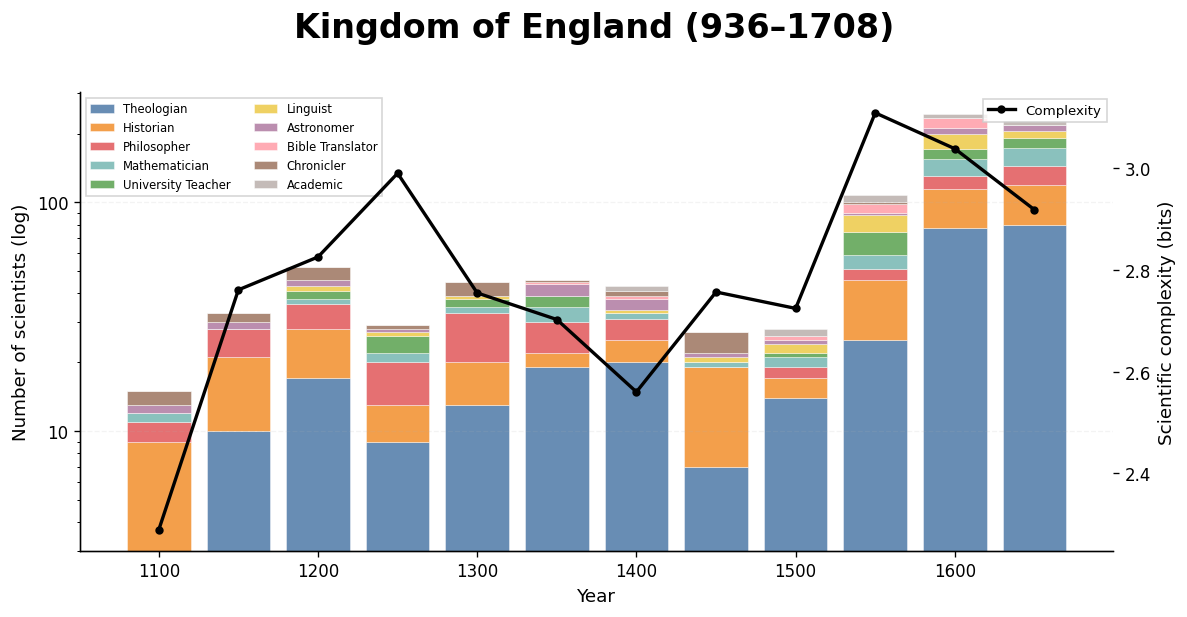

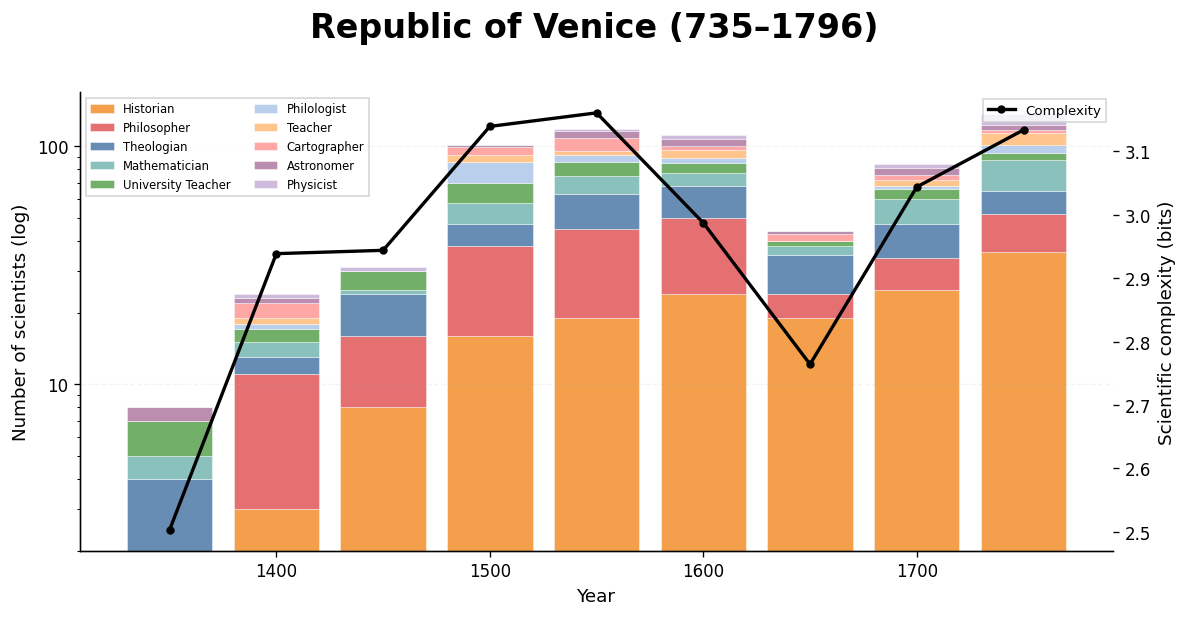

In [5]:
import matplotlib.ticker as ticker

PALETTE = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
    '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
    '#aec7e8', '#ffbb78', '#ff9896', '#c5b0d5', '#c49c94',
]

# Build a global occupation → color mapping so colors are consistent across polities
all_occs = []
for title in polity_order:
    for occ in focus_data[title]['top10']:
        if occ not in all_occs:
            all_occs.append(occ)
occ_color = {occ: PALETTE[i % len(PALETTE)] for i, occ in enumerate(all_occs)}

for polity_name in polity_order:
    d = focus_data[polity_name]
    bins = d['bins']
    top10 = d['top10']

    fig, ax = plt.subplots(figsize=(10, 5))

    bottom = np.zeros(len(bins))
    for occ in top10:
        vals = np.array(d['raw_counts'][occ], dtype=float)
        ax.bar(bins, vals, bottom=bottom, width=40, color=occ_color[occ],
               alpha=0.85, label=occ.title(), edgecolor='white', linewidth=0.3)
        bottom += vals

    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x)}' if x >= 1 else ''))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_ylabel('Number of scientists (log)', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')

    ax_r = ax.twinx()
    ax_r.plot(bins, d['entropy'], '-o', color='black', linewidth=2,
              markersize=4, zorder=5, label='Complexity')
    ax_r.set_ylabel('Scientific complexity (bits)', fontsize=11)
    ax_r.tick_params(labelsize=10)
    ax_r.spines['top'].set_visible(False)
    ax_r.legend(fontsize=8, loc='upper right', frameon=True,
                fancybox=False, edgecolor='#cccccc')

    ax.legend(fontsize=7, loc='upper left', ncol=2, frameon=True,
              fancybox=False, edgecolor='#cccccc')

    fig.suptitle(f"{polity_name} ({d['yr_start']}–{d['yr_end']})",
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 5. Individual lists

- Theologians in the Kingdom of England
- Historians in the Republic of Venice

In [ ]:
conn = sqlite3.connect(DB)

df_theologians = pl.read_database("""
    SELECT c.name_en, c.floruit_year
    FROM consolidated_database c
    WHERE c.polity_name LIKE '%Kingdom of England%'
      AND c.is_scientist = 1
      AND lower(c.occupations) LIKE '%theologian%'
    ORDER BY c.floruit_year
""", conn)
print(f"Theologians in Kingdom of England: {df_theologians.height}")
print(df_theologians)

df_historians = pl.read_database("""
    SELECT c.name_en, c.floruit_year
    FROM consolidated_database c
    WHERE c.polity_name LIKE 'Republic of Venice%'
      AND c.is_scientist = 1
      AND lower(c.occupations) LIKE '%historian%'
    ORDER BY c.floruit_year
""", conn)
print(f"\nHistorians in Republic of Venice: {df_historians.height}")
print(df_historians)

conn.close()

In [ ]:
df_theologians.drop_nulls()

In [ ]:
df_historians.drop_nulls()